
# OpenCV Learning Notebook

This notebook is a practical guide to **OpenCV (`cv2`)** and the most commonly used parts of the library.

It covers:
- Jupyter setup
- reading and writing images
- image shapes, channels, and color spaces
- resizing, cropping, flipping, and rotating
- drawing shapes and text
- thresholds, masks, and bitwise operations
- blurring and smoothing
- edge detection
- contour detection
- histograms
- morphological operations
- video capture basics
- saving images and frames
- common modules and inspection helpers

**Note:** OpenCV is a large library, so this notebook focuses on the **most used methods, functions, and features** rather than every single API entry.



## 1) Jupyter setup

Install the basics:

```bash
pip install opencv-python numpy matplotlib jupyter
jupyter notebook
```

If you want the extra OpenCV modules too:

```bash
pip install opencv-contrib-python
```

In notebooks, OpenCV images are usually shown with `matplotlib`, because `cv2.imshow()` often does not work well inside Jupyter.


In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("OpenCV version:", cv2.__version__)


OpenCV version: 4.12.0


## 2) Create a sample image so the notebook works anywhere

In [2]:

# Create a simple synthetic image
img = np.zeros((300, 400, 3), dtype=np.uint8)

# Background color
img[:] = (40, 120, 200)  # BGR in OpenCV

# Draw some shapes
cv2.rectangle(img, (40, 40), (180, 180), (0, 255, 0), thickness=3)
cv2.circle(img, (280, 120), 50, (255, 0, 0), thickness=-1)
cv2.line(img, (20, 250), (380, 250), (0, 0, 255), thickness=4)
cv2.putText(img, "OpenCV", (110, 285), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)

# Save it locally
Path("opencv_data").mkdir(exist_ok=True)
cv2.imwrite("opencv_data/sample_image.png", img)

print("Saved sample image to opencv_data/sample_image.png")


Saved sample image to opencv_data/sample_image.png


## 3) Read and display an image

Type: <class 'numpy.ndarray'>
Shape: (300, 400, 3)
Dtype: uint8


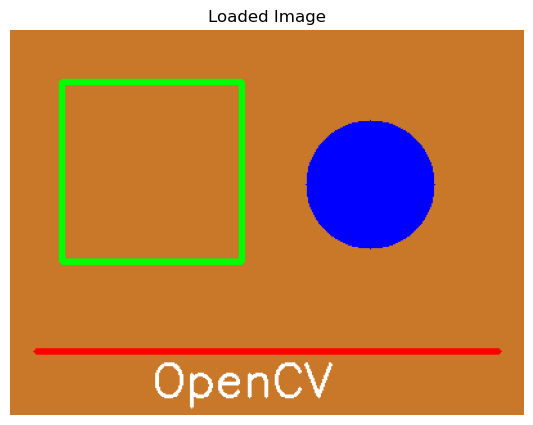

In [3]:

image = cv2.imread("opencv_data/sample_image.png")
print("Type:", type(image))
print("Shape:", image.shape)
print("Dtype:", image.dtype)

# OpenCV loads images as BGR, but matplotlib expects RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(image_rgb)
plt.title("Loaded Image")
plt.axis("off")
plt.show()


## 4) Image shape, height, width, channels

In [4]:

h, w, c = image.shape
print("Height:", h)
print("Width:", w)
print("Channels:", c)

print("Top-left pixel BGR:", image[0, 0])


Height: 300
Width: 400
Channels: 3
Top-left pixel BGR: [ 40 120 200]


## 5) Convert color spaces

Gray shape: (300, 400)
HSV shape: (300, 400, 3)
RGB shape: (300, 400, 3)


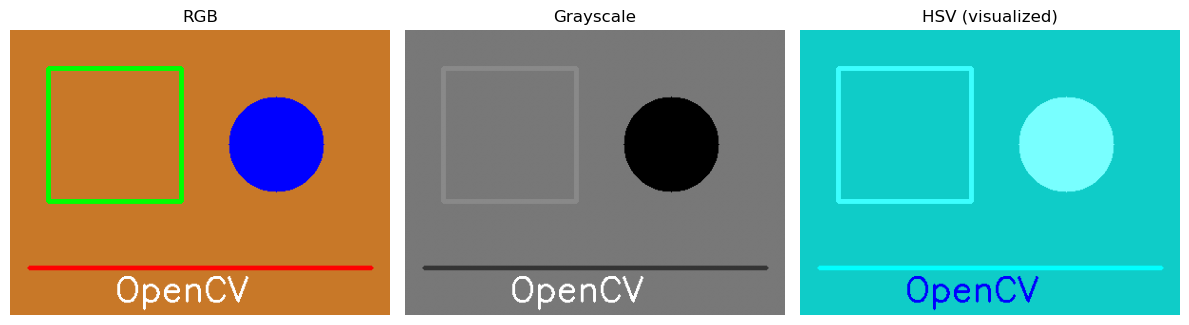

In [5]:

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Gray shape:", gray.shape)
print("HSV shape:", hsv.shape)
print("RGB shape:", rgb.shape)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hsv)
plt.title("HSV (visualized)")
plt.axis("off")

plt.tight_layout()
plt.show()


## 6) Resize images

Original: (300, 400, 3)
Small: (150, 200, 3)
Large: (450, 600, 3)


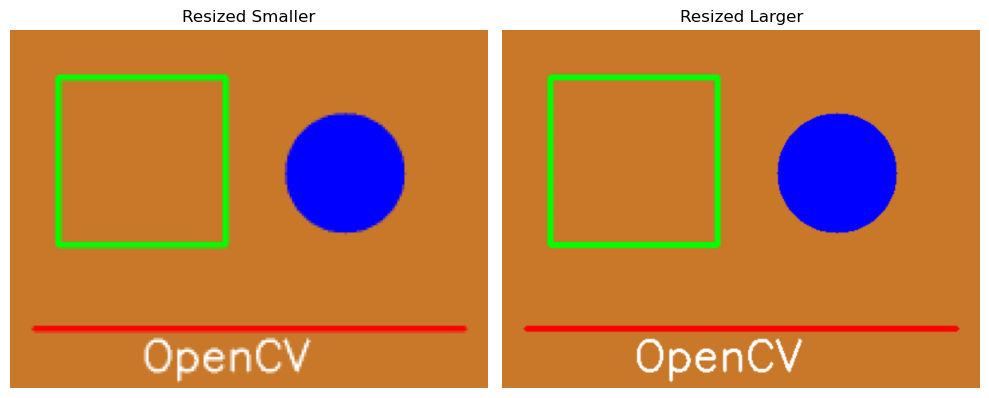

In [6]:

small = cv2.resize(image, (200, 150))
large = cv2.resize(image, None, fx=1.5, fy=1.5)

print("Original:", image.shape)
print("Small:", small.shape)
print("Large:", large.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
plt.title("Resized Smaller")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(large, cv2.COLOR_BGR2RGB))
plt.title("Resized Larger")
plt.axis("off")

plt.tight_layout()
plt.show()


## 7) Crop and slice images

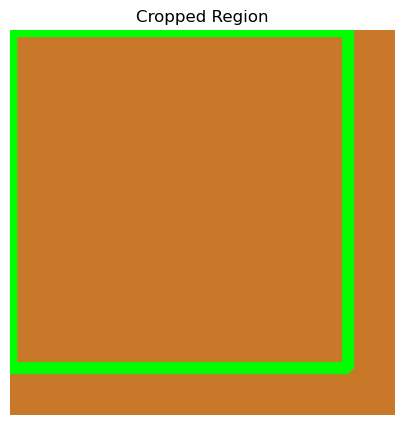

In [7]:

crop = image[40:200, 40:200]

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title("Cropped Region")
plt.axis("off")
plt.show()


## 8) Flip and rotate

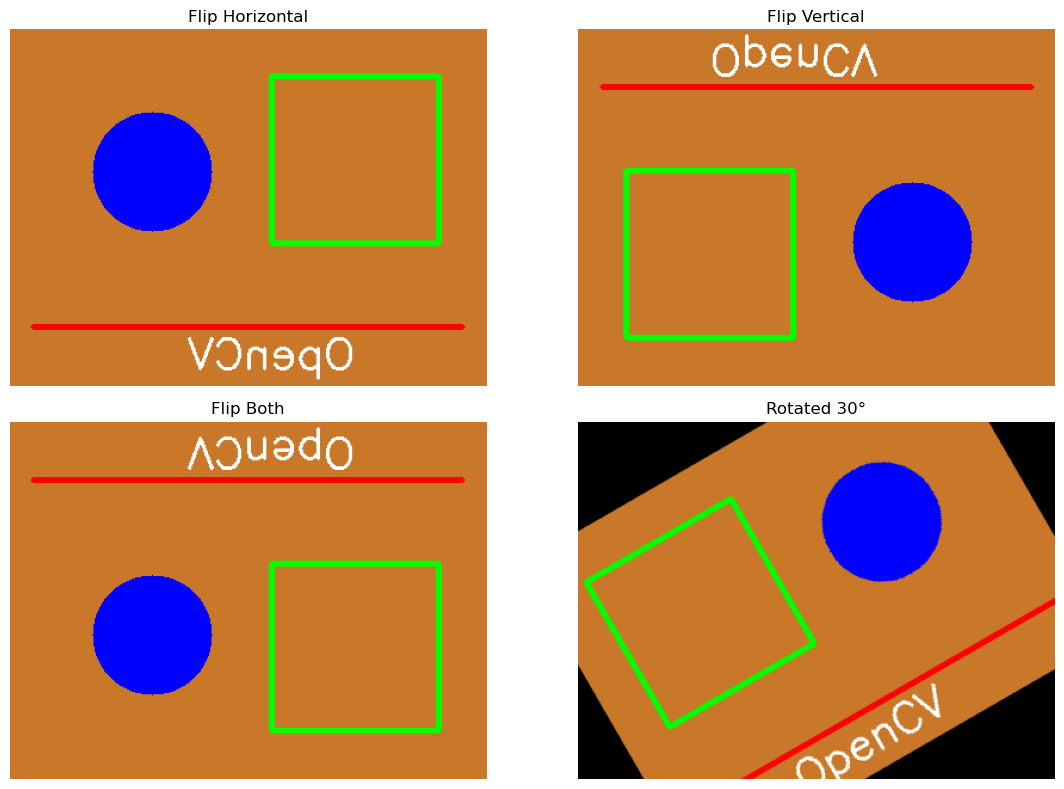

In [8]:

flip_horizontal = cv2.flip(image, 1)
flip_vertical = cv2.flip(image, 0)
flip_both = cv2.flip(image, -1)

center = (image.shape[1] // 2, image.shape[0] // 2)
rot_matrix = cv2.getRotationMatrix2D(center, 30, 1.0)
rotated = cv2.warpAffine(image, rot_matrix, (image.shape[1], image.shape[0]))

plt.figure(figsize=(12, 8))

imgs = [flip_horizontal, flip_vertical, flip_both, rotated]
titles = ["Flip Horizontal", "Flip Vertical", "Flip Both", "Rotated 30°"]

for i, (im, title) in enumerate(zip(imgs, titles), start=1):
    plt.subplot(2, 2, i)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 9) Split and merge channels

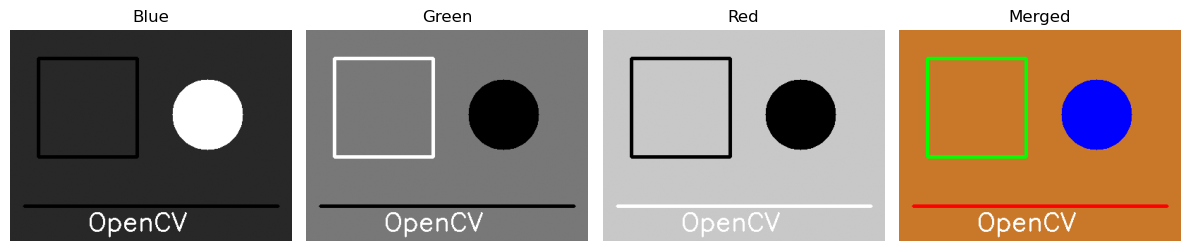

In [9]:

b, g, r = cv2.split(image)
merged = cv2.merge([b, g, r])

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(b, cmap="gray")
plt.title("Blue")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(g, cmap="gray")
plt.title("Green")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(r, cmap="gray")
plt.title("Red")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(merged, cv2.COLOR_BGR2RGB))
plt.title("Merged")
plt.axis("off")

plt.tight_layout()
plt.show()


## 10) Drawing: lines, rectangles, circles, text

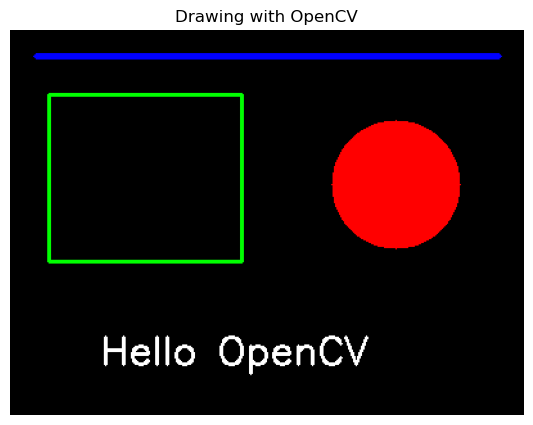

In [10]:

canvas = np.zeros((300, 400, 3), dtype=np.uint8)

cv2.line(canvas, (20, 20), (380, 20), (255, 0, 0), 3)
cv2.rectangle(canvas, (30, 50), (180, 180), (0, 255, 0), 2)
cv2.circle(canvas, (300, 120), 50, (0, 0, 255), -1)
cv2.putText(canvas, "Hello OpenCV", (70, 260), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title("Drawing with OpenCV")
plt.axis("off")
plt.show()


## 11) Image blending

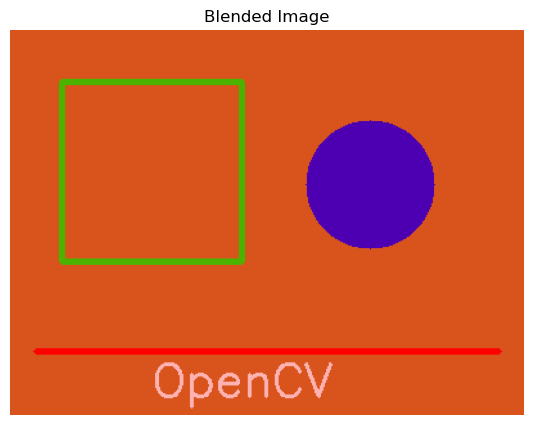

In [11]:

overlay = np.zeros_like(image)
overlay[:] = (0, 0, 255)

blended = cv2.addWeighted(image, 0.7, overlay, 0.3, 0)

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
plt.title("Blended Image")
plt.axis("off")
plt.show()


## 12) Thresholding

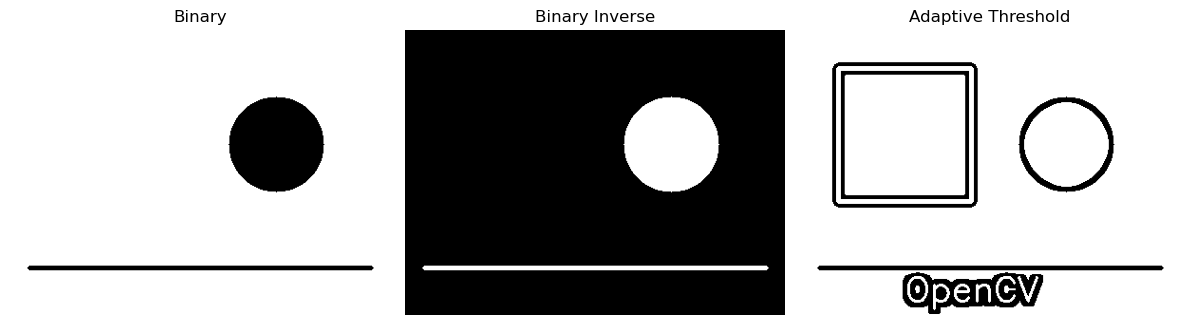

In [12]:

_, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)
_, binary_inv = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)
adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                 cv2.THRESH_BINARY, 11, 2)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(binary, cmap="gray")
plt.title("Binary")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(binary_inv, cmap="gray")
plt.title("Binary Inverse")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(adaptive, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")

plt.tight_layout()
plt.show()


## 13) Masks and bitwise operations

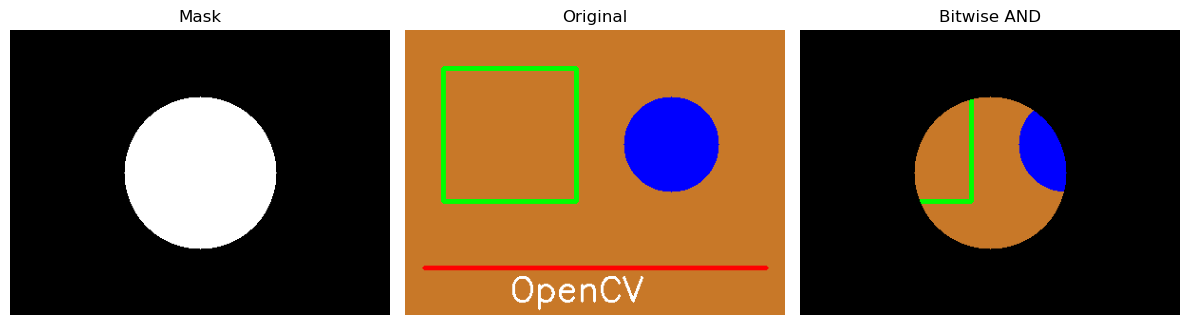

In [13]:

mask = np.zeros(gray.shape, dtype=np.uint8)
cv2.circle(mask, (200, 150), 80, 255, -1)

masked = cv2.bitwise_and(image, image, mask=mask)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(masked, cv2.COLOR_BGR2RGB))
plt.title("Bitwise AND")
plt.axis("off")

plt.tight_layout()
plt.show()


## 14) Blurring and smoothing

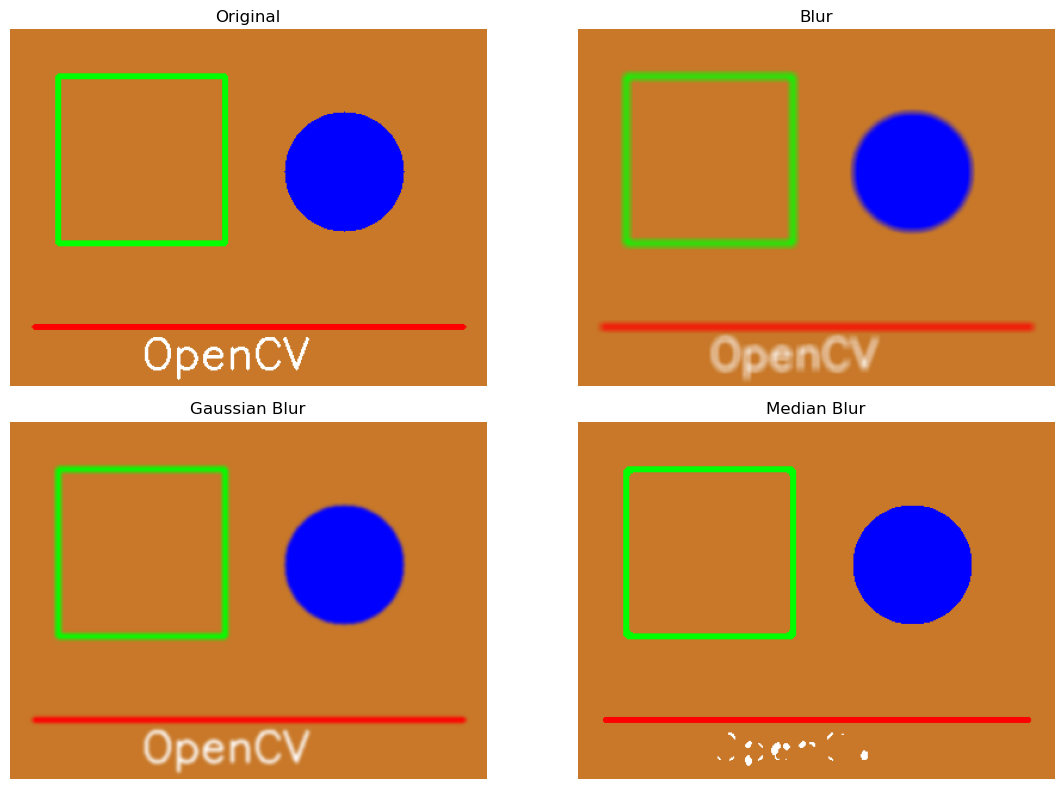

In [14]:

blur = cv2.blur(image, (7, 7))
gaussian = cv2.GaussianBlur(image, (7, 7), 0)
median = cv2.medianBlur(image, 7)

plt.figure(figsize=(12, 8))

imgs = [image, blur, gaussian, median]
titles = ["Original", "Blur", "Gaussian Blur", "Median Blur"]

for i, (im, title) in enumerate(zip(imgs, titles), start=1):
    plt.subplot(2, 2, i)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 15) Edge detection

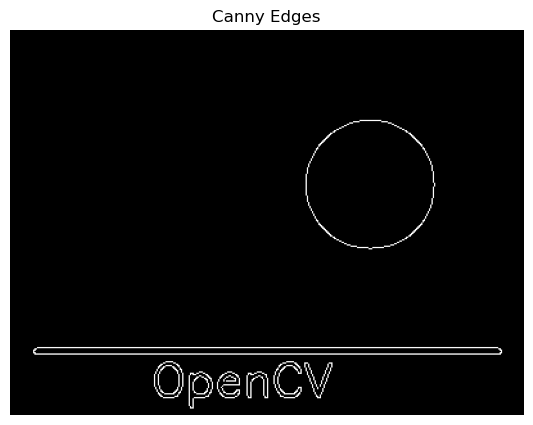

In [15]:

edges = cv2.Canny(gray, 50, 150)

plt.figure(figsize=(8, 5))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")
plt.show()


## 16) Morphological operations

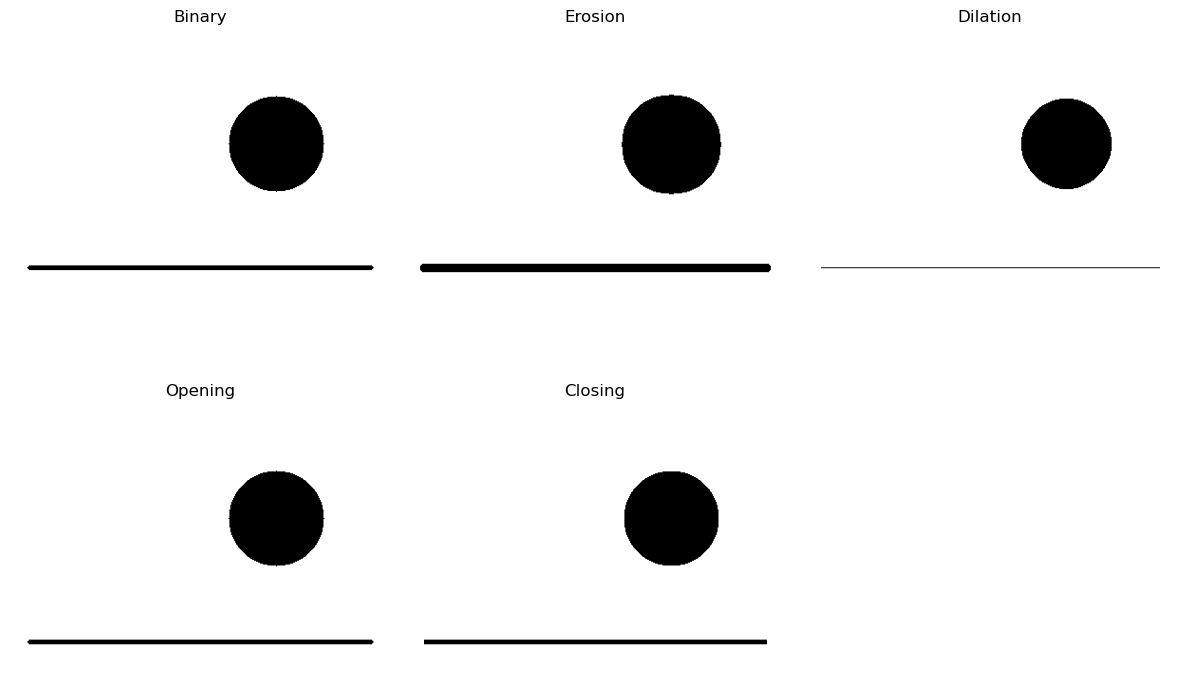

In [16]:

kernel = np.ones((5, 5), np.uint8)

erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(12, 8))

imgs = [binary, erosion, dilation, opening, closing]
titles = ["Binary", "Erosion", "Dilation", "Opening", "Closing"]

for i, (im, title) in enumerate(zip(imgs, titles), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(im, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 17) Find contours

Number of contours found: 1


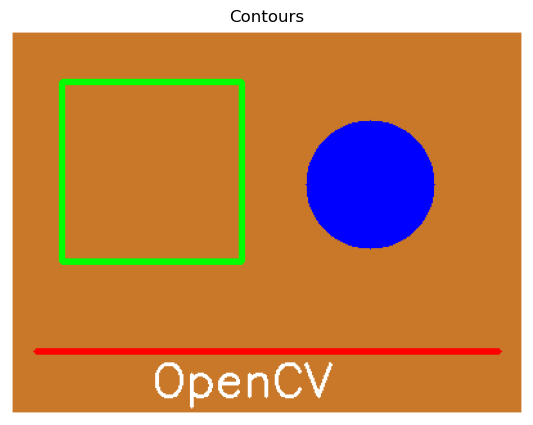

In [17]:

contour_image = image.copy()
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

cv2.drawContours(contour_image, contours, -1, (255, 255, 255), 2)

print("Number of contours found:", len(contours))

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title("Contours")
plt.axis("off")
plt.show()


## 18) Bounding boxes around contours

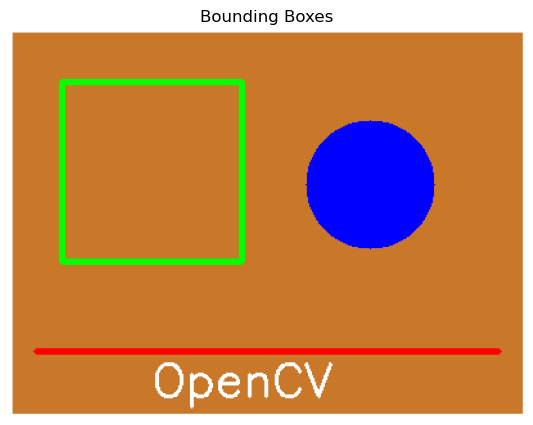

In [18]:

boxed = image.copy()

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(boxed, (x, y), (x + w, y + h), (255, 255, 255), 2)

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
plt.title("Bounding Boxes")
plt.axis("off")
plt.show()


## 19) Histograms

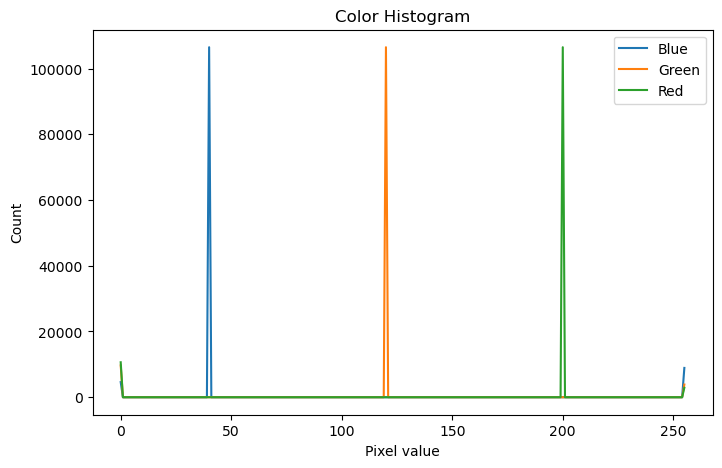

In [19]:

hist_b = cv2.calcHist([image], [0], None, [256], [0, 256])
hist_g = cv2.calcHist([image], [1], None, [256], [0, 256])
hist_r = cv2.calcHist([image], [2], None, [256], [0, 256])

plt.figure(figsize=(8, 5))
plt.plot(hist_b, label="Blue")
plt.plot(hist_g, label="Green")
plt.plot(hist_r, label="Red")
plt.title("Color Histogram")
plt.xlabel("Pixel value")
plt.ylabel("Count")
plt.legend()
plt.show()


## 20) Geometric transforms: affine warp

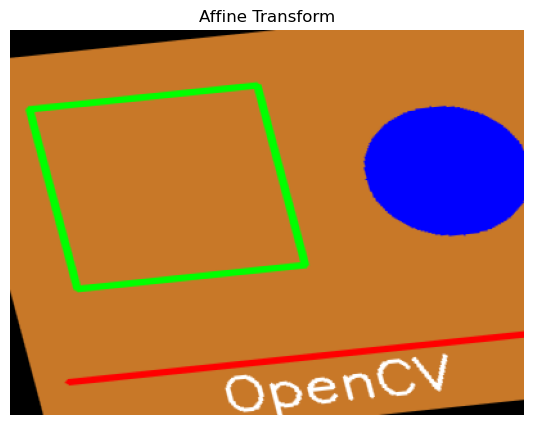

In [20]:

rows, cols = image.shape[:2]

pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
pts2 = np.float32([[30, 70], [220, 50], [70, 220]])

M = cv2.getAffineTransform(pts1, pts2)
warped = cv2.warpAffine(image, M, (cols, rows))

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title("Affine Transform")
plt.axis("off")
plt.show()


## 21) Perspective transform

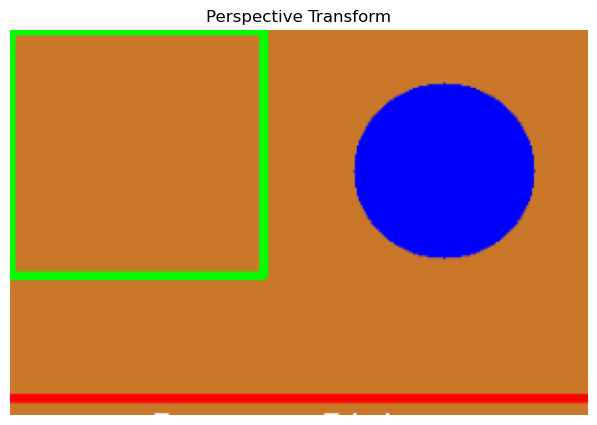

In [21]:

pts1 = np.float32([[40, 40], [360, 40], [40, 260], [360, 260]])
pts2 = np.float32([[0, 0], [300, 0], [0, 200], [300, 200]])

P = cv2.getPerspectiveTransform(pts1, pts2)
perspective = cv2.warpPerspective(image, P, (300, 200))

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(perspective, cv2.COLOR_BGR2RGB))
plt.title("Perspective Transform")
plt.axis("off")
plt.show()


## 22) Simple feature detection with corners

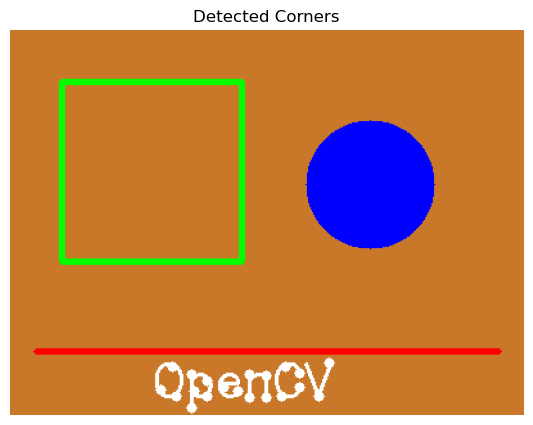

In [22]:

corners_img = image.copy()
corners = cv2.goodFeaturesToTrack(gray, maxCorners=20, qualityLevel=0.01, minDistance=10)

if corners is not None:
    corners = corners.astype(np.int32)
    for corner in corners:
        x, y = corner.ravel()
        cv2.circle(corners_img, (x, y), 4, (255, 255, 255), -1)

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(corners_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Corners")
plt.axis("off")
plt.show()


## 23) Video capture basics

In [23]:

print("Basic webcam/video code example:")
print(r'''
cap = cv2.VideoCapture(0)  # 0 = default webcam

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    cv2.imshow("Video", gray_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
''')


Basic webcam/video code example:

cap = cv2.VideoCapture(0)  # 0 = default webcam

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    cv2.imshow("Video", gray_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()



## 24) Save images

In [24]:

cv2.imwrite("opencv_data/gray_image.png", gray)
cv2.imwrite("opencv_data/edges.png", edges)
cv2.imwrite("opencv_data/boxed.png", boxed)

print("Saved:")
print("- opencv_data/gray_image.png")
print("- opencv_data/edges.png")
print("- opencv_data/boxed.png")


Saved:
- opencv_data/gray_image.png
- opencv_data/edges.png
- opencv_data/boxed.png


## 25) Useful constants and common flags

In [25]:

common_constants = {
    "Image reading": ["cv2.IMREAD_COLOR", "cv2.IMREAD_GRAYSCALE", "cv2.IMREAD_UNCHANGED"],
    "Color conversion": ["cv2.COLOR_BGR2RGB", "cv2.COLOR_BGR2GRAY", "cv2.COLOR_BGR2HSV"],
    "Thresholding": ["cv2.THRESH_BINARY", "cv2.THRESH_BINARY_INV", "cv2.THRESH_OTSU"],
    "Contours": ["cv2.RETR_EXTERNAL", "cv2.RETR_TREE", "cv2.CHAIN_APPROX_SIMPLE"],
    "Morphology": ["cv2.MORPH_OPEN", "cv2.MORPH_CLOSE", "cv2.MORPH_GRADIENT"],
    "Fonts": ["cv2.FONT_HERSHEY_SIMPLEX", "cv2.FONT_HERSHEY_COMPLEX"],
}

for category, items in common_constants.items():
    print(f"\n{category}:")
    print(", ".join(items))



Image reading:
cv2.IMREAD_COLOR, cv2.IMREAD_GRAYSCALE, cv2.IMREAD_UNCHANGED

Color conversion:
cv2.COLOR_BGR2RGB, cv2.COLOR_BGR2GRAY, cv2.COLOR_BGR2HSV

Thresholding:
cv2.THRESH_BINARY, cv2.THRESH_BINARY_INV, cv2.THRESH_OTSU

Contours:
cv2.RETR_EXTERNAL, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE

Morphology:
cv2.MORPH_OPEN, cv2.MORPH_CLOSE, cv2.MORPH_GRADIENT

Fonts:
cv2.FONT_HERSHEY_SIMPLEX, cv2.FONT_HERSHEY_COMPLEX


## 26) Common OpenCV functions by category

In [ ]:

common_functions = {
    "Read/write": ["cv2.imread", "cv2.imwrite", "cv2.VideoCapture"],
    "Display/conversion": ["cv2.cvtColor", "cv2.split", "cv2.merge"],
    "Transforms": ["cv2.resize", "cv2.flip", "cv2.getRotationMatrix2D", "cv2.warpAffine", "cv2.warpPerspective"],
    "Drawing": ["cv2.line", "cv2.rectangle", "cv2.circle", "cv2.putText", "cv2.drawContours"],
    "Threshold/masks": ["cv2.threshold", "cv2.adaptiveThreshold", "cv2.bitwise_and", "cv2.addWeighted"],
    "Blur/edges": ["cv2.blur", "cv2.GaussianBlur", "cv2.medianBlur", "cv2.Canny"],
    "Morphology": ["cv2.erode", "cv2.dilate", "cv2.morphologyEx"],
    "Contours/features": ["cv2.findContours", "cv2.boundingRect", "cv2.goodFeaturesToTrack"],
    "Analysis": ["cv2.calcHist"],
}

for category, funcs in common_functions.items():
    print(f"\n{category}:")
    print(", ".join(funcs))


## 27) Inspect library names

In [ ]:

public_cv2_names = [name for name in dir(cv2) if not name.startswith("_")]
print("Some public names in cv2:")
print(public_cv2_names[:250])
print("\nTotal shown:", len(public_cv2_names))



## 28) Practice exercises

1. Read an image and display it in RGB with `matplotlib`.
2. Convert an image to grayscale and HSV.
3. Resize an image to half size.
4. Crop a region from the image.
5. Draw a rectangle and some text on a blank image.
6. Use thresholding to create a binary image.
7. Run Canny edge detection.
8. Find contours and draw bounding boxes.
9. Compute a color histogram.
10. Save the processed result to disk.



## 29) Summary

You now have a notebook that introduces the main OpenCV workflow:

- reading and writing images
- color conversions
- resizing, cropping, flipping, rotating
- drawing and annotation
- thresholding and masking
- blurring and edge detection
- morphology and contours
- feature basics
- histograms
- video capture basics

This is the core path used in many beginner and intermediate computer vision projects.
